In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_recall_curve, roc_curve, auc

from utils.model_utils import validate, train, evaluate, get_tensor_dataset, get_data_loader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")
val_df = pd.read_csv("data/val.csv")

In [4]:
label = 'label'

train_dataset = get_tensor_dataset(train_df, label)
test_dataset = get_tensor_dataset(test_df, label)
val_dataset = get_tensor_dataset(val_df, label)

print(train_dataset)
print(test_dataset)
print(val_dataset)

In [5]:
BATCH_SIZE = 32
train_loader = get_data_loader(train_dataset, BATCH_SIZE)
test_loader = get_data_loader(test_dataset, BATCH_SIZE)
val_loader = get_data_loader(val_dataset, BATCH_SIZE)

In [6]:
model = nn.Sequential(
    nn.Linear(1024, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(256, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.4),

    nn.Linear(64, 1)
)
model.to(device)
print(model)

Sequential(
  (0): Linear(in_features=1024, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=256, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.4, inplace=False)
  (8): Linear(in_features=64, out_features=1, bias=True)
)


In [7]:
num_pos = train_df["label"].sum()
num_neg = len(train_df) - num_pos

pos_weight = torch.tensor([num_neg / num_pos]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
THRESHOLD = 0.5

In [8]:
best_loss = float('inf')
patience = 2
counter = 0

for epoch in range(50):
    print("Epoch:", epoch)
    train(
        model=model,
        loss_function=criterion,
        threshold=THRESHOLD,
        optimizer=optimizer,
        train_loader=train_loader,
        device=device
    )
    val_loss = validate(
        model=model,
        loss_function=criterion,
        threshold=THRESHOLD,
        val_loader=val_loader,
        device=device
    )
    print("-" * 40)

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "../model_repository/pneumonia_model_phase_2.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

Epoch: 0
Train - Loss: 0.6285 Accuracy: 0.4465
Valid - Loss: 0.5327 Accuracy: 0.5869
----------------------------------------
Epoch: 1
Train - Loss: 0.5286 Accuracy: 0.6128
Valid - Loss: 0.5135 Accuracy: 0.6386
----------------------------------------
Epoch: 2
Train - Loss: 0.4964 Accuracy: 0.6921
Valid - Loss: 0.4911 Accuracy: 0.6816
----------------------------------------
Epoch: 3
Train - Loss: 0.4709 Accuracy: 0.7231
Valid - Loss: 0.4842 Accuracy: 0.6902
----------------------------------------
Epoch: 4
Train - Loss: 0.4537 Accuracy: 0.7471
Valid - Loss: 0.4779 Accuracy: 0.7194
----------------------------------------
Epoch: 5
Train - Loss: 0.4430 Accuracy: 0.7607
Valid - Loss: 0.4726 Accuracy: 0.7332
----------------------------------------
Epoch: 6
Train - Loss: 0.4170 Accuracy: 0.7743
Valid - Loss: 0.4727 Accuracy: 0.7108
----------------------------------------
Epoch: 7
Train - Loss: 0.4022 Accuracy: 0.7850
Valid - Loss: 0.4802 Accuracy: 0.7367
---------------------------------

===== EVALUATION METRICS =====
Accuracy  : 0.7474
Precision : 0.6007
Recall    : 0.8119
F1 Score  : 0.6905

Confusion Matrix:
 [[271 109]
 [ 38 164]]

Detailed Classification Report:

              precision    recall  f1-score   support

         0.0       0.88      0.71      0.79       380
         1.0       0.60      0.81      0.69       202

    accuracy                           0.75       582
   macro avg       0.74      0.76      0.74       582
weighted avg       0.78      0.75      0.75       582



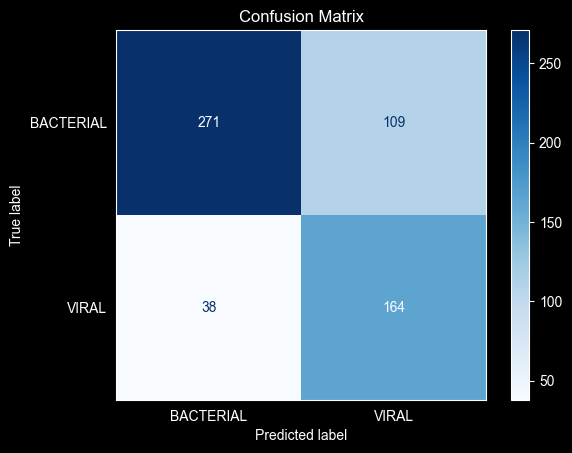

In [9]:
evaluate(model=model,
         threshold=THRESHOLD,
         data_loader=test_loader,
         device=device,
         labels=["BACTERIAL", "VIRAL"])

In [10]:
model.load_state_dict(torch.load("../model_repository/pneumonia_model_phase_2.pth"))
all_probs = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch).squeeze()
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
j_scores = tpr - fpr
best_threshold = roc_thresholds[np.argmax(j_scores)]

print("Chosen threshold:", best_threshold)

Chosen threshold: 0.4177126


===== EVALUATION METRICS =====
Accuracy  : 0.7766
Precision : 0.6782
Recall    : 0.6782
F1 Score  : 0.6782

Confusion Matrix:
 [[315  65]
 [ 65 137]]

Detailed Classification Report:

              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83       380
         1.0       0.68      0.68      0.68       202

    accuracy                           0.78       582
   macro avg       0.75      0.75      0.75       582
weighted avg       0.78      0.78      0.78       582



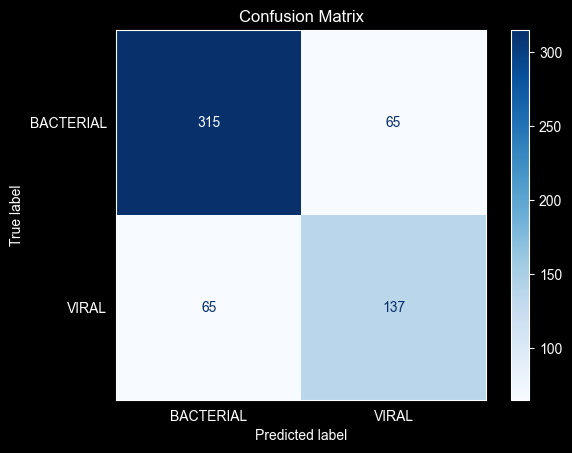

In [11]:
evaluate(model=model,
         threshold=best_threshold,
         data_loader=test_loader,
         device=device,
         labels=["BACTERIAL", "VIRAL"])

Best Threshold: 0.4177126
AUC: 0.8323232059353692


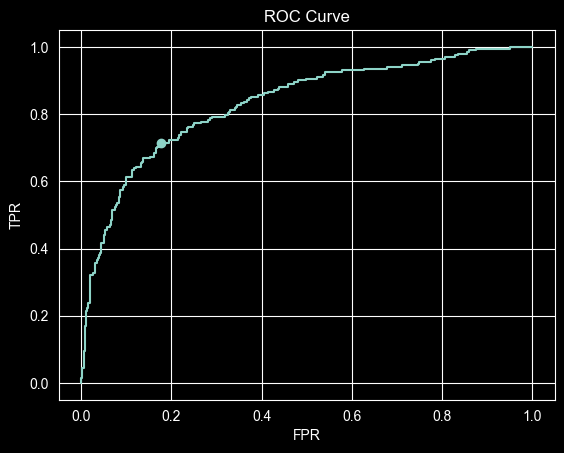

In [12]:
from matplotlib import pyplot as plt

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Best threshold (Youden J)
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("AUC:", roc_auc)

# Plot
plt.plot(fpr, tpr)
plt.scatter(fpr[best_idx], tpr[best_idx])  # best point
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()